# OpenCV (Part 1): Reading Images, BGR Gotcha, Channels, and Resizing

OpenCV (`cv2`) is a computer-vision library built for images and video, including real-time applications.  
Even though it’s famous for tasks like face detection and tracking, it’s also very useful for microscopy:

- detecting cells/nuclei (object detection)
- tracking cells over time (video/time-series analysis)
- fast pre-processing before segmentation (denoise, edges, contrast)

In this first OpenCV intro we’ll focus on **two core building blocks**:

1. **Splitting & merging channels** (for multi-channel images)
2. **Resizing (scaling)** images

We’ll also cover an extremely important OpenCV “gotcha”:

> ✅ OpenCV loads color images as **BGR**, not RGB.

---

## Install OpenCV (Python)

If you don’t have it:   
`pip install opencv-python`

(If you want additional modules, you can install `opencv-contrib-python`, but start with opencv-python.)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

---

### 1) Read an Image (Color vs Grayscale)
**Read as color (default)**

In [30]:
img = cv2.imread("doplerUS1.jpg", 1)  # 1 = color - 0 = gray-level
print(img.shape)  # (height, width, channels)

(294, 171, 3)


Example output: (194, 259, 3) → color image.   

Let's see the image itself:

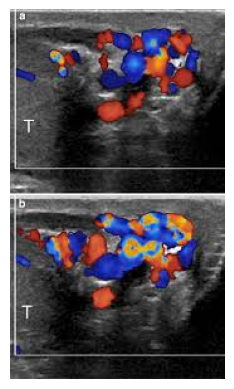

In [31]:
plt.imshow(img)
plt.axis("off")
plt.show()

**Read as grayscale**

Shape: (294, 171)


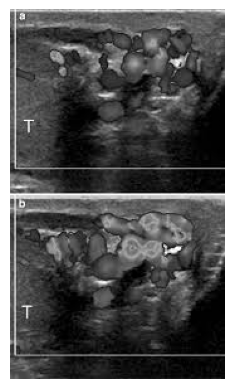

In [33]:
gray = cv2.imread("doplerUS1.jpg", 0)  #     0 --> grayscale
print(f"Shape: {gray.shape}")  #   (194, 259) --> height and width

plt.imshow(gray, cmap = "gray")
plt.axis("off")
plt.show()

**Read unchanged (keeps alpha channel if present)**

Shape: (294, 171)


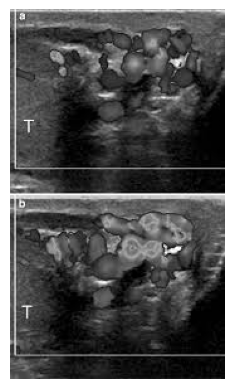

In [35]:
unchanged = cv2.imread("doplerUS1.jpg", 2)  # unchanged (may include alpha)
print(f"Shape: {unchanged.shape}")

plt.imshow(unchanged, cmap = "gray")
plt.axis("off")
plt.show()


---

### 2) Pixel Values + The BGR vs RGB Trap

OpenCV uses **BGR** channel order by default.

In [37]:
px = img[145, 80]   # somewhere in the middle
print(px)        # e.g. [63, 63, 63]

[63 63 63]


If you assume RGB, you’ll interpret this incorrectly.
- OpenCV: `[B, G, R]`
- so `[63, 63, 63]` means **blue = 186, green = 5, red = 79**   

**Check corners (quick sanity check)**

In [38]:
h, w = img.shape[:2]

corners = {
    "top-left": img[0, 0],
    "top-right": img[0, w-1],
    "bottom-left": img[h-1, 0],
    "bottom-right": img[h-1, w-1]
}

for name, val in corners.items():
    print(name, val)

top-left [185 185 185]
top-right [185 185 185]
bottom-left [103 103 103]
bottom-right [15 15 15]


---

### 3) Display Images with OpenCV

OpenCV uses its own window system:

In [39]:
cv2.imshow("Image", img)
cv2.waitKey(0)              # 0 = wait forever until a key press
cv2.destroyAllWindows()

**Important**: Always pair `imshow()` with `waitKey()` and `destroyAllWindows()` or your script may hang.

---

### 4) Split Channels (Two Ways)
#### A) NumPy slicing

In [40]:
blue = img[:, :, 0]
green = img[:, :, 1]
red = img[:, :, 2]

Visualize each:

In [41]:
cv2.imshow("Blue channel", blue)
cv2.imshow("Green channel", green)
cv2.imshow("Red channel", red)
cv2.waitKey(0)
cv2.destroyAllWindows()

**Why does `imshow()` show a “grayscale” image here?**   

OpenCV sees a single-channel (2D) array, so it displays it as grayscale intensity:
- brighter pixel = higher blue value
- darker pixel = lower blue value
So it’s not “blue colored”, it’s “how much blue is there” shown as brightness.

#### B) OpenCV split

In [42]:
b, g, r = cv2.split(img)

This is equivalent to slicing, but often more readable.

---

### 5) Merge Channels Back

If you modify channels separately (e.g., denoise just one channel), you can combine them:

In [43]:
merged = cv2.merge([b, g, r])
cv2.imshow("Merged", merged)
cv2.waitKey(0)
cv2.destroyAllWindows()

✅ Merge expects BGR order if you want to preserve original colors.

---

### 6) Convert BGR → RGB for Matplotlib (Very Common!)

Matplotlib expects RGB.   
If you plot a BGR image directly, colors look wrong.

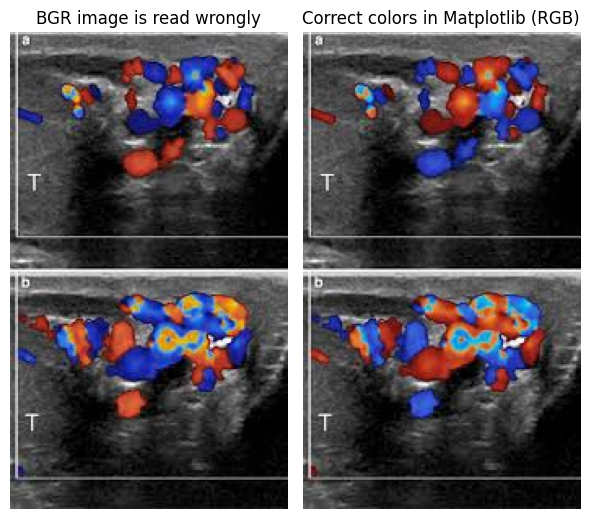

In [ ]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(6, 7))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.axis("off")
plt.title("BGR image is read wrongly")

plt.subplot(1, 2, 2)
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Correct colors in Matplotlib (RGB)")


plt.tight_layout()
plt.show()

This is one of the most important OpenCV “tricks”.

---

### 7) Resize Images

There are two common ways:

#### A) Resize by scale factors (fx, fy)
You tell OpenCV “multiply the size by this factor”:

Original: (294, 171, 3)
Resized: (588, 342, 3)


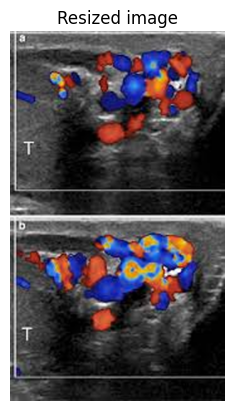

In [53]:
resized = cv2.resize(
    img,
    None,
    fx=2.0,
    fy=2.0,
    interpolation=cv2.INTER_CUBIC
)
print("Original:", img.shape)
print("Resized:", resized.shape)

plt.imshow(resized)
plt.title("Resized image")
plt.axis("off")
plt.show()

✅ fx=2.0 means: new width = old width × 2   
✅ fy=2.0 means: new height = old height × 2

**Why is None there?**
Because the second argument is `dsize` (explicit size).   
If you’re not providing an explicit size, you put `None` so OpenCV knows to compute it from fx/fy.

#### B) Resize to explicit dimensions (width, height)
You directly tell OpenCV the final (width, height):

Original: (294, 171, 3)
Resized: (600, 800, 3)


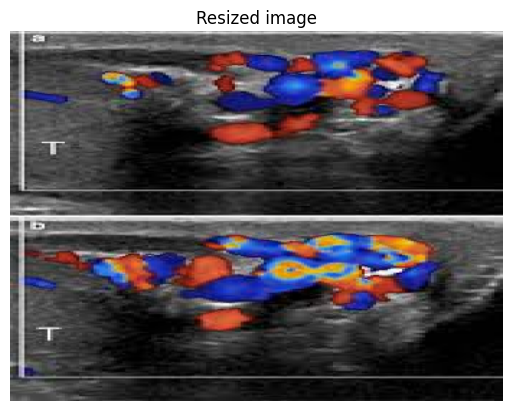

In [52]:
new_w, new_h = 800, 600
resized2 = cv2.resize(
    img, 
    (new_w, new_h), 
    interpolation=cv2.INTER_AREA)

print("Original:", img.shape)
print("Resized:", resized2.shape)

plt.imshow(resized2)
plt.title("Resized image")
plt.axis("off")
plt.show()

✅ You control the exact output size.

---

**Interpolation: Which One Should You Use?**

When you scale up, OpenCV must invent new pixels between existing ones.   
Interpolation decides how it invents them:
- `cv2.INTER_NEAREST` → fastest, blocky
- `cv2.INTER_LINEAR` → good default
- `cv2.INTER_CUBIC` → smoother for zooming in (slower)
- `cv2.INTER_AREA` → best for shrinking (downscaling)

A good rule of thumb:
- Upscale: `INTER_CUBIC` or `INTER_LINEAR`
- Downscale: `INTER_AREA`
- 

Example:

In [56]:
small = cv2.resize(
    img, 
    None, 
    fx=0.5, 
    fy=0.5, 
    interpolation=cv2.INTER_AREA)

big   = cv2.resize(
    img, 
    None, 
    fx=2.0, 
    fy=2.0, 
    interpolation=cv2.INTER_CUBIC)

print("Small:", small.shape)
print("Big:", big.shape)

Small: (147, 86, 3)
Big: (588, 342, 3)


---

### Visualizations

#### A) Show original vs resized side-by-side (Matplotlib)

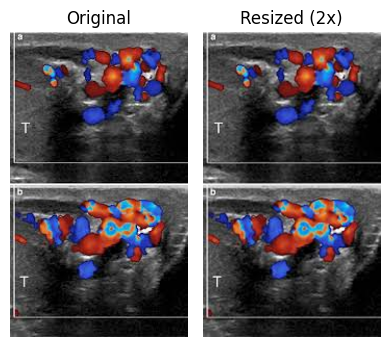

In [61]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
big_rgb = cv2.cvtColor(big, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.subplot(1,2,1); plt.imshow(img_rgb); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(big_rgb); plt.title("Resized (2x)"); plt.axis("off")
plt.tight_layout()
plt.show()

#### B) Visualize channels as grayscale + as “colored overlays”

Grayscale view:

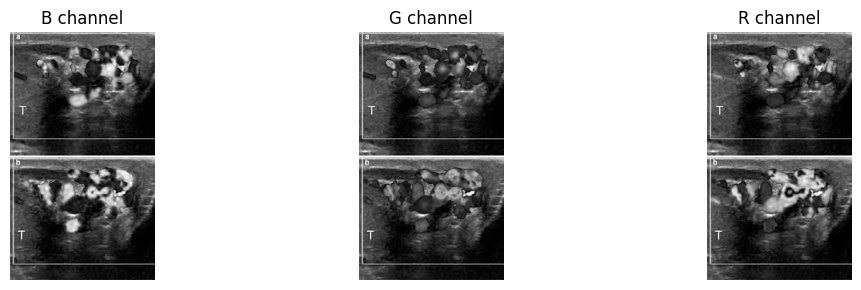

In [63]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); plt.imshow(b, cmap="gray"); plt.title("B channel"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(g, cmap="gray"); plt.title("G channel"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(r, cmap="gray"); plt.title("R channel"); plt.axis("off")
plt.tight_layout()
plt.show()


Colored channel overlays (helps intuition):

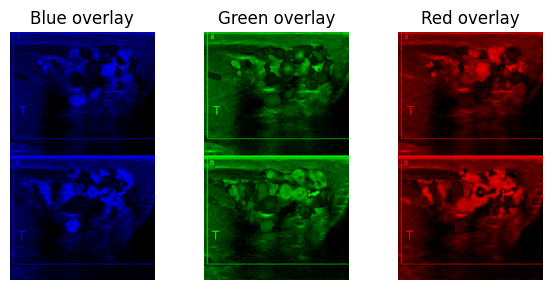

In [65]:
zeros = np.zeros_like(b)

b_col = cv2.merge([b, zeros, zeros])
g_col = cv2.merge([zeros, g, zeros])
r_col = cv2.merge([zeros, zeros, r])

# Convert to RGB for plotting
b_col = cv2.cvtColor(b_col, cv2.COLOR_BGR2RGB)
g_col = cv2.cvtColor(g_col, cv2.COLOR_BGR2RGB)
r_col = cv2.cvtColor(r_col, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,3))
plt.subplot(1,3,1); plt.imshow(b_col); plt.title("Blue overlay"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(g_col); plt.title("Green overlay"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(r_col); plt.title("Red overlay"); plt.axis("off")
plt.tight_layout()
plt.show()


---

Key Takeaways
- OpenCV loads images as NumPy arrays
- Color order is **BGR**, not RGB
- You can split channels via slicing or cv2.split()
- Use `cv2.merge()` to recombine channels
- Use `cv2.cvtColor(..., COLOR_BGR2RGB)` before plotting with Matplotlib
- Choose interpolation based on whether you upsample or downsample